# Exploratory Data Analysis — Crop Recommendation System

**MSc Big Data and Data Science Technology (ML Project)**

---

This notebook performs comprehensive exploratory data analysis on two datasets:

1. **Primary:** Crop Recommendation Dataset (Kaggle) — the training data for our ML model
2. **Secondary:** Soil Physical and Chemical Properties Dataset (Mendeley Data) — for contextual soil fertility discussion

## Notebook Structure

1. Setup and data loading
2. Schema validation and data cleaning
3. Descriptive statistics
4. Target variable analysis (class distribution)
5. Feature distributions (histograms + KDE)
6. Correlation analysis
7. Per-crop feature behaviour (box plots + violin plots)
8. Bivariate relationships (pairplot)
9. Outlier detection
10. Secondary dataset: Soil properties analysis
11. Key findings summary

---

## 1. Setup and Data Loading

In [1]:
# ── Imports ──────────────────────────────────────────────────
import sys
from pathlib import Path

# Make src/ importable from the notebook
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Project modules ──────────────────────────────────────────
from data_preprocessing import (
    load_crop_dataset, load_soil_dataset,
    validate_schema, clean_dataset,
    get_summary_stats, get_class_distribution,
    FEATURE_COLUMNS, TARGET_COLUMN, FEATURE_BOUNDS
)

# ── Plotting setup ───────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams.update({
    'figure.dpi':      120,
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'axes.spines.top':  False,
    'axes.spines.right': False,
    'font.family':      'DejaVu Sans',
})

print('✓ Libraries loaded')
print(f'  pandas     {pd.__version__}')
print(f'  numpy      {np.__version__}')
print(f'  seaborn    {sns.__version__}')

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [ ]:
# ── Load the primary dataset ─────────────────────────────────
raw_df = load_crop_dataset()

print(f'Shape: {raw_df.shape[0]} rows × {raw_df.shape[1]} columns\n')
raw_df.head(10)

10:13:27 | INFO | Loaded crop dataset: 2200 rows × 8 columns from 'crop_dataset.csv'


Shape: 2200 rows × 8 columns



,N,P,K,temperature,humidity,ph,rainfall,label
0,111.62,22.72,59.89,29.464655,93.925074,6.375088,25.392108,muskmelon
1,103.14,22.48,46.08,24.046485,92.541881,6.200232,52.605093,watermelon
2,45.75,58.95,54.03,35.420852,94.477678,7.881026,150.545164,papaya
3,42.26,66.36,59.31,34.773256,93.793210,6.573171,171.417750,papaya
4,19.90,123.88,220.21,13.665857,93.629281,6.183571,116.586579,apple
5,2.09,17.78,26.76,36.526223,55.260773,5.569015,88.019308,mango
6,3.70,111.94,196.60,10.793018,91.750062,6.897175,124.829231,apple
7,34.70,70.33,29.88,32.297972,60.634867,6.413282,61.907973,mothbeans
8,28.96,30.98,25.56,34.901456,84.911504,6.411358,54.405796,mungbean
9,35.83,56.24,29.28,21.901937,70.020526,7.414061,41.422589,lentil


In [ ]:
# ── Quick data overview ──────────────────────────────────────
print('── Data Types ──')
print(raw_df.dtypes)

print('\n── Missing values per column ──')
missing = raw_df.isnull().sum()
if missing.sum() == 0:
    print('No missing values detected ✓')
else:
    print(missing[missing > 0])

print('\n── Duplicate rows ──')
print(f'Exact duplicates: {raw_df.duplicated().sum()}')

print('\n── Memory usage ──')
print(f'{raw_df.memory_usage(deep=True).sum() / 1024:.1f} KB')

── Data Types ──
N              float64
P              float64
K              float64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

── Missing values per column ──
No missing values detected ✓

── Duplicate rows ──
Exact duplicates: 0

── Memory usage ──
258.2 KB


## 2. Schema Validation and Data Cleaning

We apply the same cleaning pipeline that is used during training. This ensures consistency between exploratory analysis and the production ML pipeline.

In [ ]:
# ── Validate schema ──────────────────────────────────────────
validate_schema(raw_df)

# ── Apply cleaning pipeline ──────────────────────────────────
df = clean_dataset(raw_df)

print(f'\nBefore cleaning: {raw_df.shape[0]} rows')
print(f'After cleaning:  {df.shape[0]} rows')
print(f'Rows removed:    {raw_df.shape[0] - df.shape[0]}')

10:13:27 | INFO | Schema validation passed ✓
10:13:27 | INFO | Starting cleaning — 2200 rows
10:13:27 | INFO | After duplicate removal: 2200 rows (dropped 0)
10:13:27 | INFO | After missing-value drop: 2200 rows (dropped 0)
10:13:27 | INFO | Cleaning complete. Final: 2200 rows (total removed: 0)



Before cleaning: 2200 rows
After cleaning:  2200 rows
Rows removed:    0


## 3. Descriptive Statistics

We compute summary statistics including skewness and kurtosis — these help us understand the shape of each distribution and decide whether transformations might be helpful during modelling.

In [ ]:
stats = get_summary_stats(df)
stats

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
N,2200.0,46.5740,39.8799,0.0100,11.7575,29.6350,85.4150,139.8300,0.5351,-1.2266
P,2200.0,56.7157,30.5796,5.0800,34.4400,52.9050,74.5650,144.9300,0.7223,0.1295
K,2200.0,52.0835,52.4905,5.0200,22.3700,35.9400,55.3550,224.4600,2.3254,4.3494
temperature,2200.0,25.9335,7.0630,0.2501,22.6364,26.7286,30.7546,41.9801,-0.8339,0.9962
humidity,2200.0,73.6471,21.9978,14.2390,60.9150,82.1594,91.2260,96.9996,-1.1615,0.5102
ph,2200.0,6.4634,0.6931,3.5068,6.0715,6.5102,6.8928,8.4819,-0.5544,1.6159
rainfall,2200.0,107.8069,53.8877,20.0277,64.0879,102.3721,149.7784,297.8310,0.5424,-0.1789


In [ ]:
# ── Interpretation of skewness and kurtosis ──────────────────
print('── Distribution Shape Analysis ──\n')
for feat in FEATURE_COLUMNS:
    skew = stats.loc[feat, 'skewness']
    kurt = stats.loc[feat, 'kurtosis']

    # Skewness interpretation
    if abs(skew) < 0.5:
        skew_label = 'approximately symmetric'
    elif abs(skew) < 1.0:
        skew_label = 'moderately skewed'
    else:
        skew_label = 'highly skewed'

    direction = '→ right' if skew > 0 else '→ left' if skew < 0 else ''
    print(f'{feat:<13} | skew = {skew:+.3f} ({skew_label} {direction})')

── Distribution Shape Analysis ──

N             | skew = +0.535 (moderately skewed → right)
P             | skew = +0.722 (moderately skewed → right)
K             | skew = +2.325 (highly skewed → right)
temperature   | skew = -0.834 (moderately skewed → left)
humidity      | skew = -1.161 (highly skewed → left)
ph            | skew = -0.554 (moderately skewed → left)
rainfall      | skew = +0.542 (moderately skewed → right)


## 4. Target Variable Analysis (Class Distribution)

For classification problems, the target distribution is critical. A severely imbalanced dataset would require techniques like SMOTE, stratified sampling, or class weights. A balanced dataset is much easier to model and provides clean accuracy baselines.

In [ ]:
dist = get_class_distribution(df)
print(f'Total classes: {len(dist)}')
print(f'Total records: {dist["count"].sum()}')
print(f'\nMin per class: {dist["count"].min()}')
print(f'Max per class: {dist["count"].max()}')
print(f'Imbalance ratio: {dist["count"].max() / dist["count"].min():.2f}×')
dist

Total classes: 22
Total records: 2200

Min per class: 100
Max per class: 100
Imbalance ratio: 1.00×


,count,pct_%
muskmelon,100,4.55
watermelon,100,4.55
cotton,100,4.55
grapes,100,4.55
kidneybeans,100,4.55
rice,100,4.55
pigeonpeas,100,4.55
chickpea,100,4.55
orange,100,4.55
coffee,100,4.55


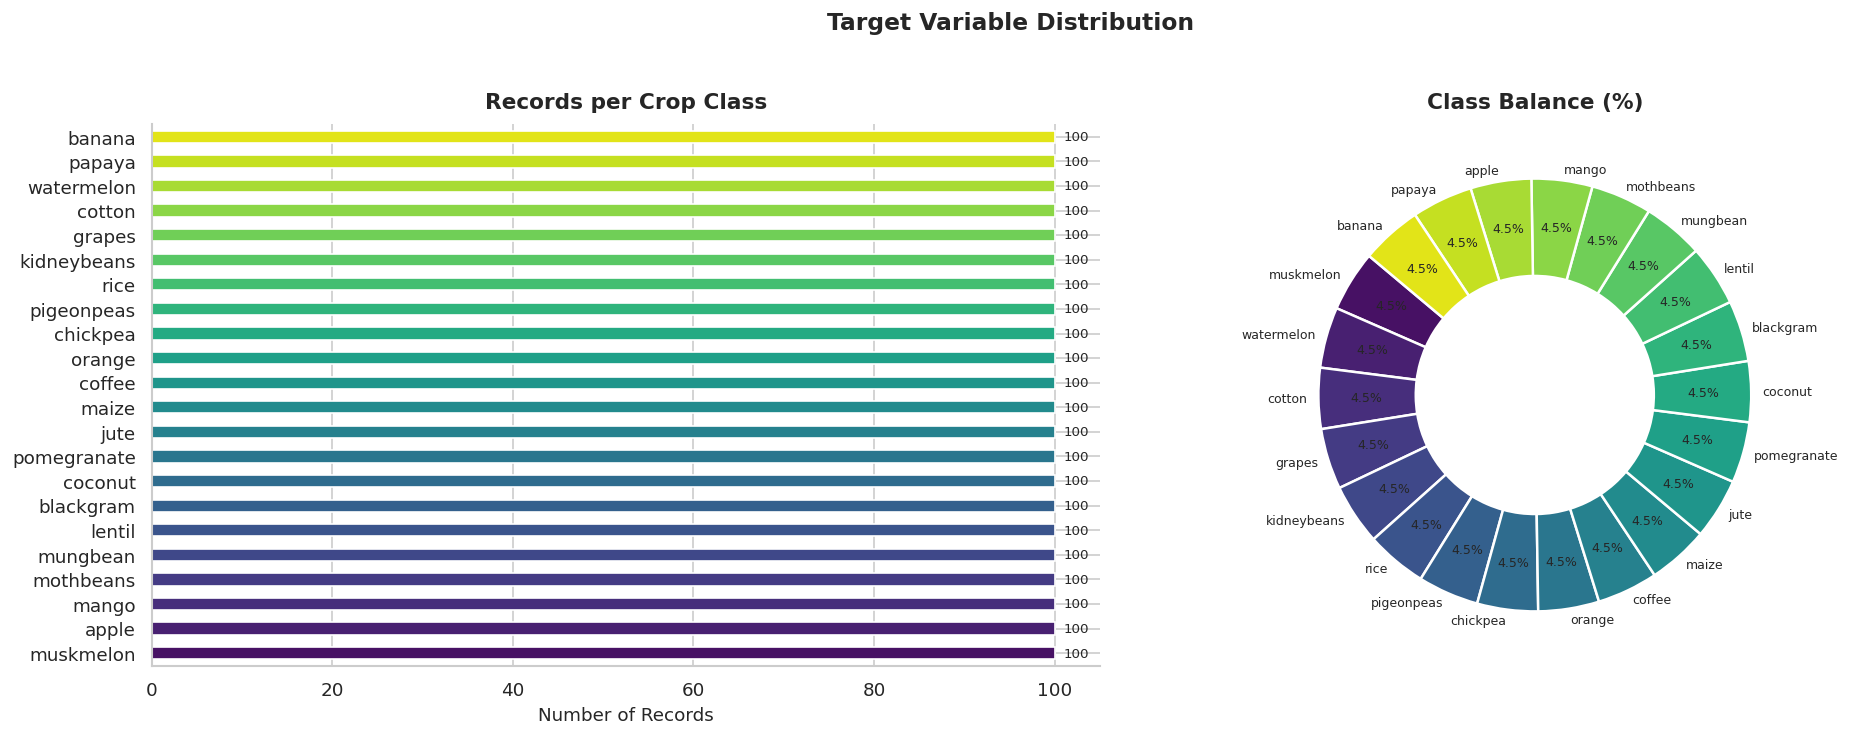


💡 KEY INSIGHT:
   Dataset is perfectly (or near-perfectly) balanced.
   → No resampling required for multiclass classification.


In [ ]:
# ── Visualise class distribution: bar + pie ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
colours = sns.color_palette('viridis', len(dist))

# Horizontal bar chart
sorted_dist = dist.sort_values('count')
sorted_dist['count'].plot(kind='barh', ax=axes[0], color=colours, edgecolor='white')
axes[0].set_title('Records per Crop Class', fontweight='bold', pad=10)
axes[0].set_xlabel('Number of Records')
axes[0].set_ylabel('')
for i, v in enumerate(sorted_dist['count']):
    axes[0].text(v + 1, i, str(v), va='center', fontsize=8)

# Donut chart
wedge_props = dict(width=0.45, edgecolor='white', linewidth=1.5)
axes[1].pie(
    dist['count'], labels=dist.index,
    autopct='%1.1f%%', startangle=140, colors=colours,
    pctdistance=0.78, labeldistance=1.05,
    textprops={'fontsize': 7.5}, wedgeprops=wedge_props
)
axes[1].set_title('Class Balance (%)', fontweight='bold', pad=10)
axes[1].set_ylabel('')

plt.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Key insight ──
print('\n💡 KEY INSIGHT:')
if (dist['count'].max() - dist['count'].min()) <= 5:
    print('   Dataset is perfectly (or near-perfectly) balanced.')
    print('   → No resampling required for multiclass classification.')
else:
    print(f'   Imbalance ratio {dist["count"].max() / dist["count"].min():.1f}× detected.')
    print('   → Consider stratified sampling or class weights.')

## 5. Feature Distributions (Histograms + KDE)

Each feature is visualised with a histogram overlaid with a Kernel Density Estimate (KDE). This reveals whether distributions are unimodal, bimodal, or multimodal, and whether they are skewed.

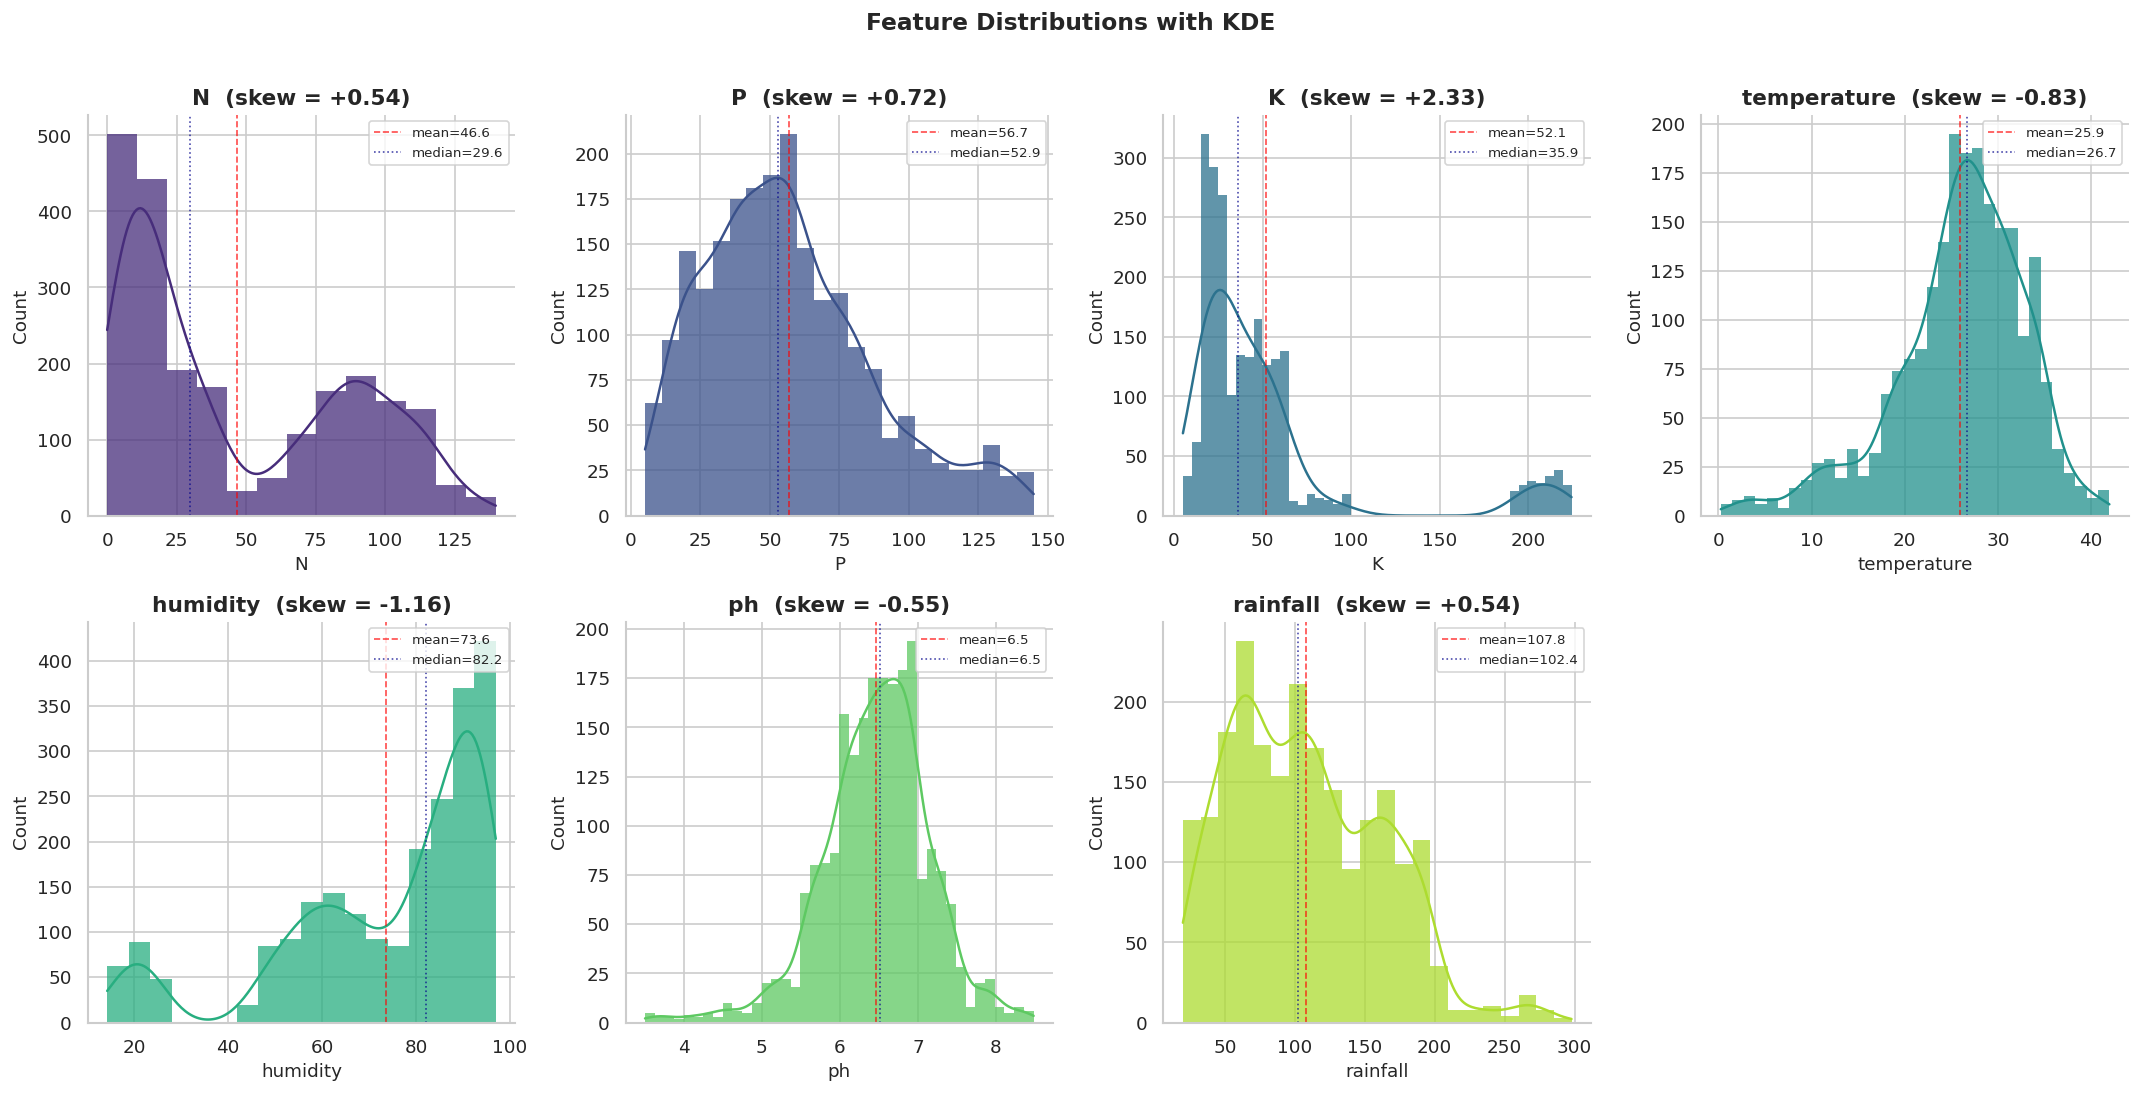

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
pal = sns.color_palette('viridis', 7)

for i, col in enumerate(FEATURE_COLUMNS):
    sns.histplot(df[col], kde=True, ax=axes[i], color=pal[i], alpha=0.75, linewidth=0)

    mean_val = df[col].mean()
    median_val = df[col].median()

    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1, alpha=0.7, label=f'mean={mean_val:.1f}')
    axes[i].axvline(median_val, color='darkblue', linestyle=':', linewidth=1, alpha=0.7, label=f'median={median_val:.1f}')

    skew = df[col].skew()
    axes[i].set_title(f'{col}  (skew = {skew:+.2f})', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].legend(fontsize=8, loc='upper right')

axes[-1].axis('off')
plt.suptitle('Feature Distributions with KDE', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

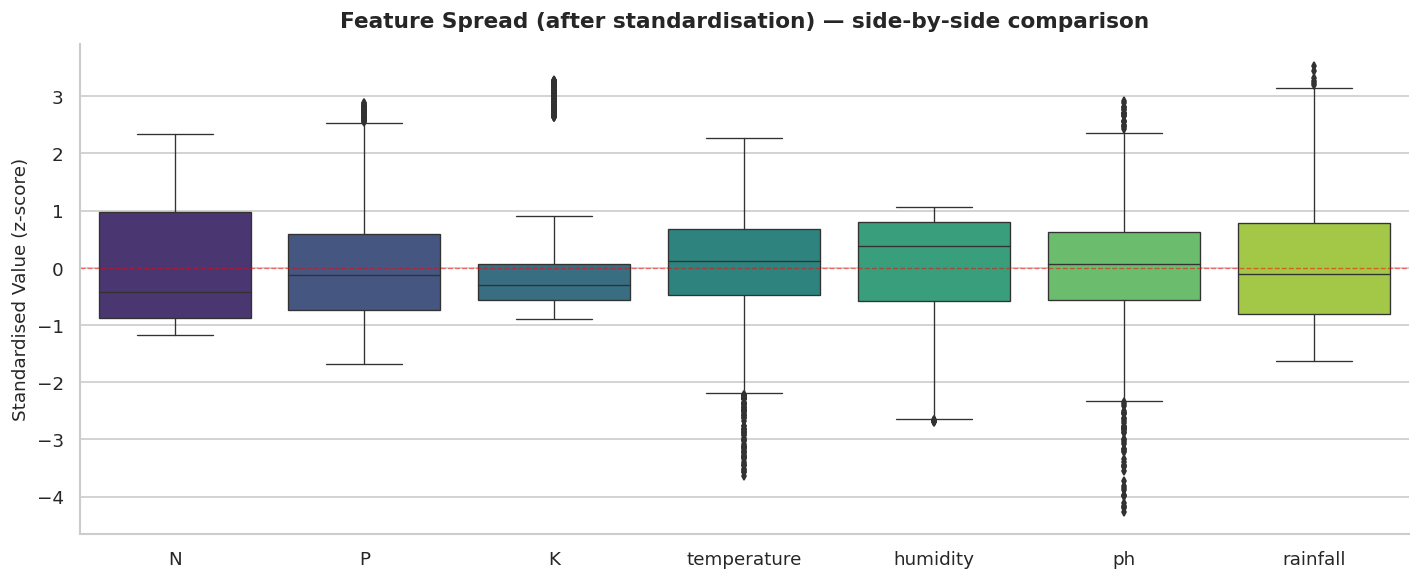


💡 This plot helps identify which features have the most variance
   and which contain the most extreme values (outliers).


In [ ]:
# ── Box plots of all features side-by-side (after standardisation for comparison) ──
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled = pd.DataFrame(
    scaler.fit_transform(df[FEATURE_COLUMNS]),
    columns=FEATURE_COLUMNS
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=scaled, ax=ax, palette='viridis',
            showfliers=True, fliersize=3, linewidth=0.8)
ax.set_title('Feature Spread (after standardisation) — side-by-side comparison',
             fontweight='bold', pad=10)
ax.set_ylabel('Standardised Value (z-score)')
ax.axhline(0, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.show()

print('\n💡 This plot helps identify which features have the most variance')
print('   and which contain the most extreme values (outliers).')

## 6. Correlation Analysis

A correlation matrix reveals whether features carry redundant information. High correlation (|r| > 0.8) between features could cause multicollinearity issues in linear models (though tree-based models are robust to this).

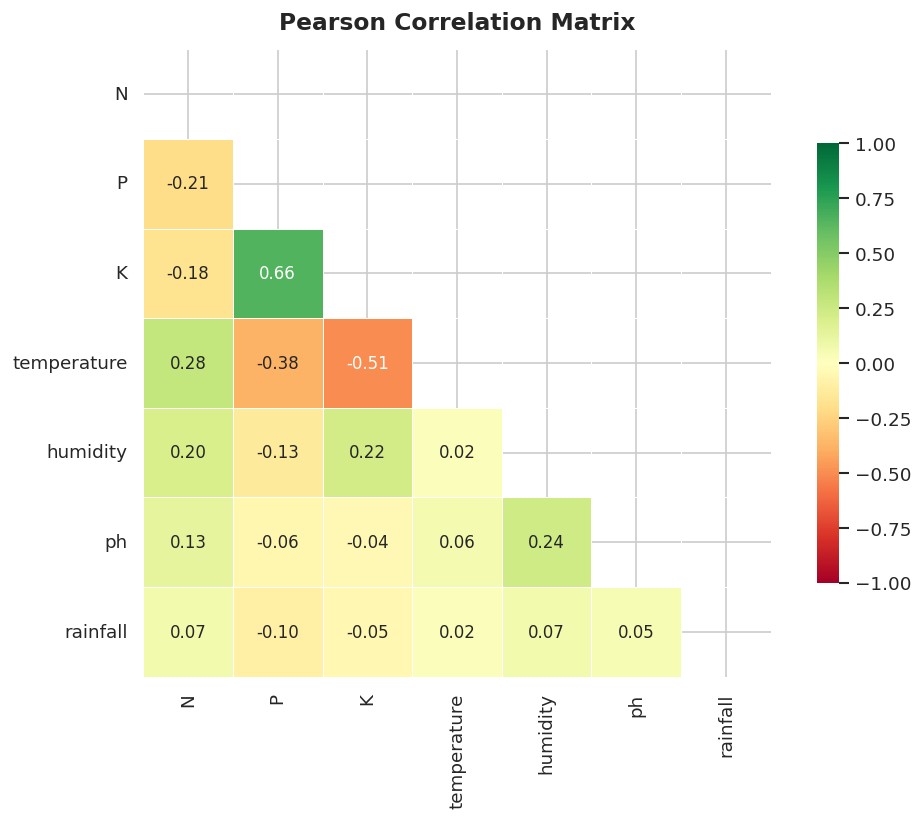


── Top 5 Strongest Correlations (abs value) ──

  P            ↔ K           : r = +0.655  (positive)
  K            ↔ temperature : r = -0.506  (negative)
  P            ↔ temperature : r = -0.379  (negative)
  N            ↔ temperature : r = +0.284  (positive)
  humidity     ↔ ph          : r = +0.238  (positive)

💡 Maximum absolute correlation: 0.655
   → Some feature pairs show notable correlation.


In [ ]:
# ── Correlation heatmap ──────────────────────────────────────
corr = df[FEATURE_COLUMNS].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, linewidths=0.5,
    square=True, ax=ax, cbar_kws={'shrink': 0.7},
    annot_kws={'fontsize': 10}, vmin=-1, vmax=1
)
ax.set_title('Pearson Correlation Matrix', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

# ── Highlight the strongest correlations ──
print('\n── Top 5 Strongest Correlations (abs value) ──\n')
pairs = []
for i in range(len(FEATURE_COLUMNS)):
    for j in range(i+1, len(FEATURE_COLUMNS)):
        f1, f2 = FEATURE_COLUMNS[i], FEATURE_COLUMNS[j]
        pairs.append((f1, f2, corr.loc[f1, f2]))

pairs.sort(key=lambda x: abs(x[2]), reverse=True)
for f1, f2, r in pairs[:5]:
    direction = 'positive' if r > 0 else 'negative'
    print(f'  {f1:<12} ↔ {f2:<12}: r = {r:+.3f}  ({direction})')

max_abs = max(abs(p[2]) for p in pairs)
print(f'\n💡 Maximum absolute correlation: {max_abs:.3f}')
if max_abs < 0.5:
    print('   → Features are largely independent. Multicollinearity is not a concern.')
else:
    print('   → Some feature pairs show notable correlation.')

## 7. Per-Crop Feature Behaviour (Box Plots & Violin Plots)

Box plots sorted by median value show which features discriminate best between crops. Features whose medians span widely across crops are strong predictors; features whose medians cluster tightly provide less discriminative information.

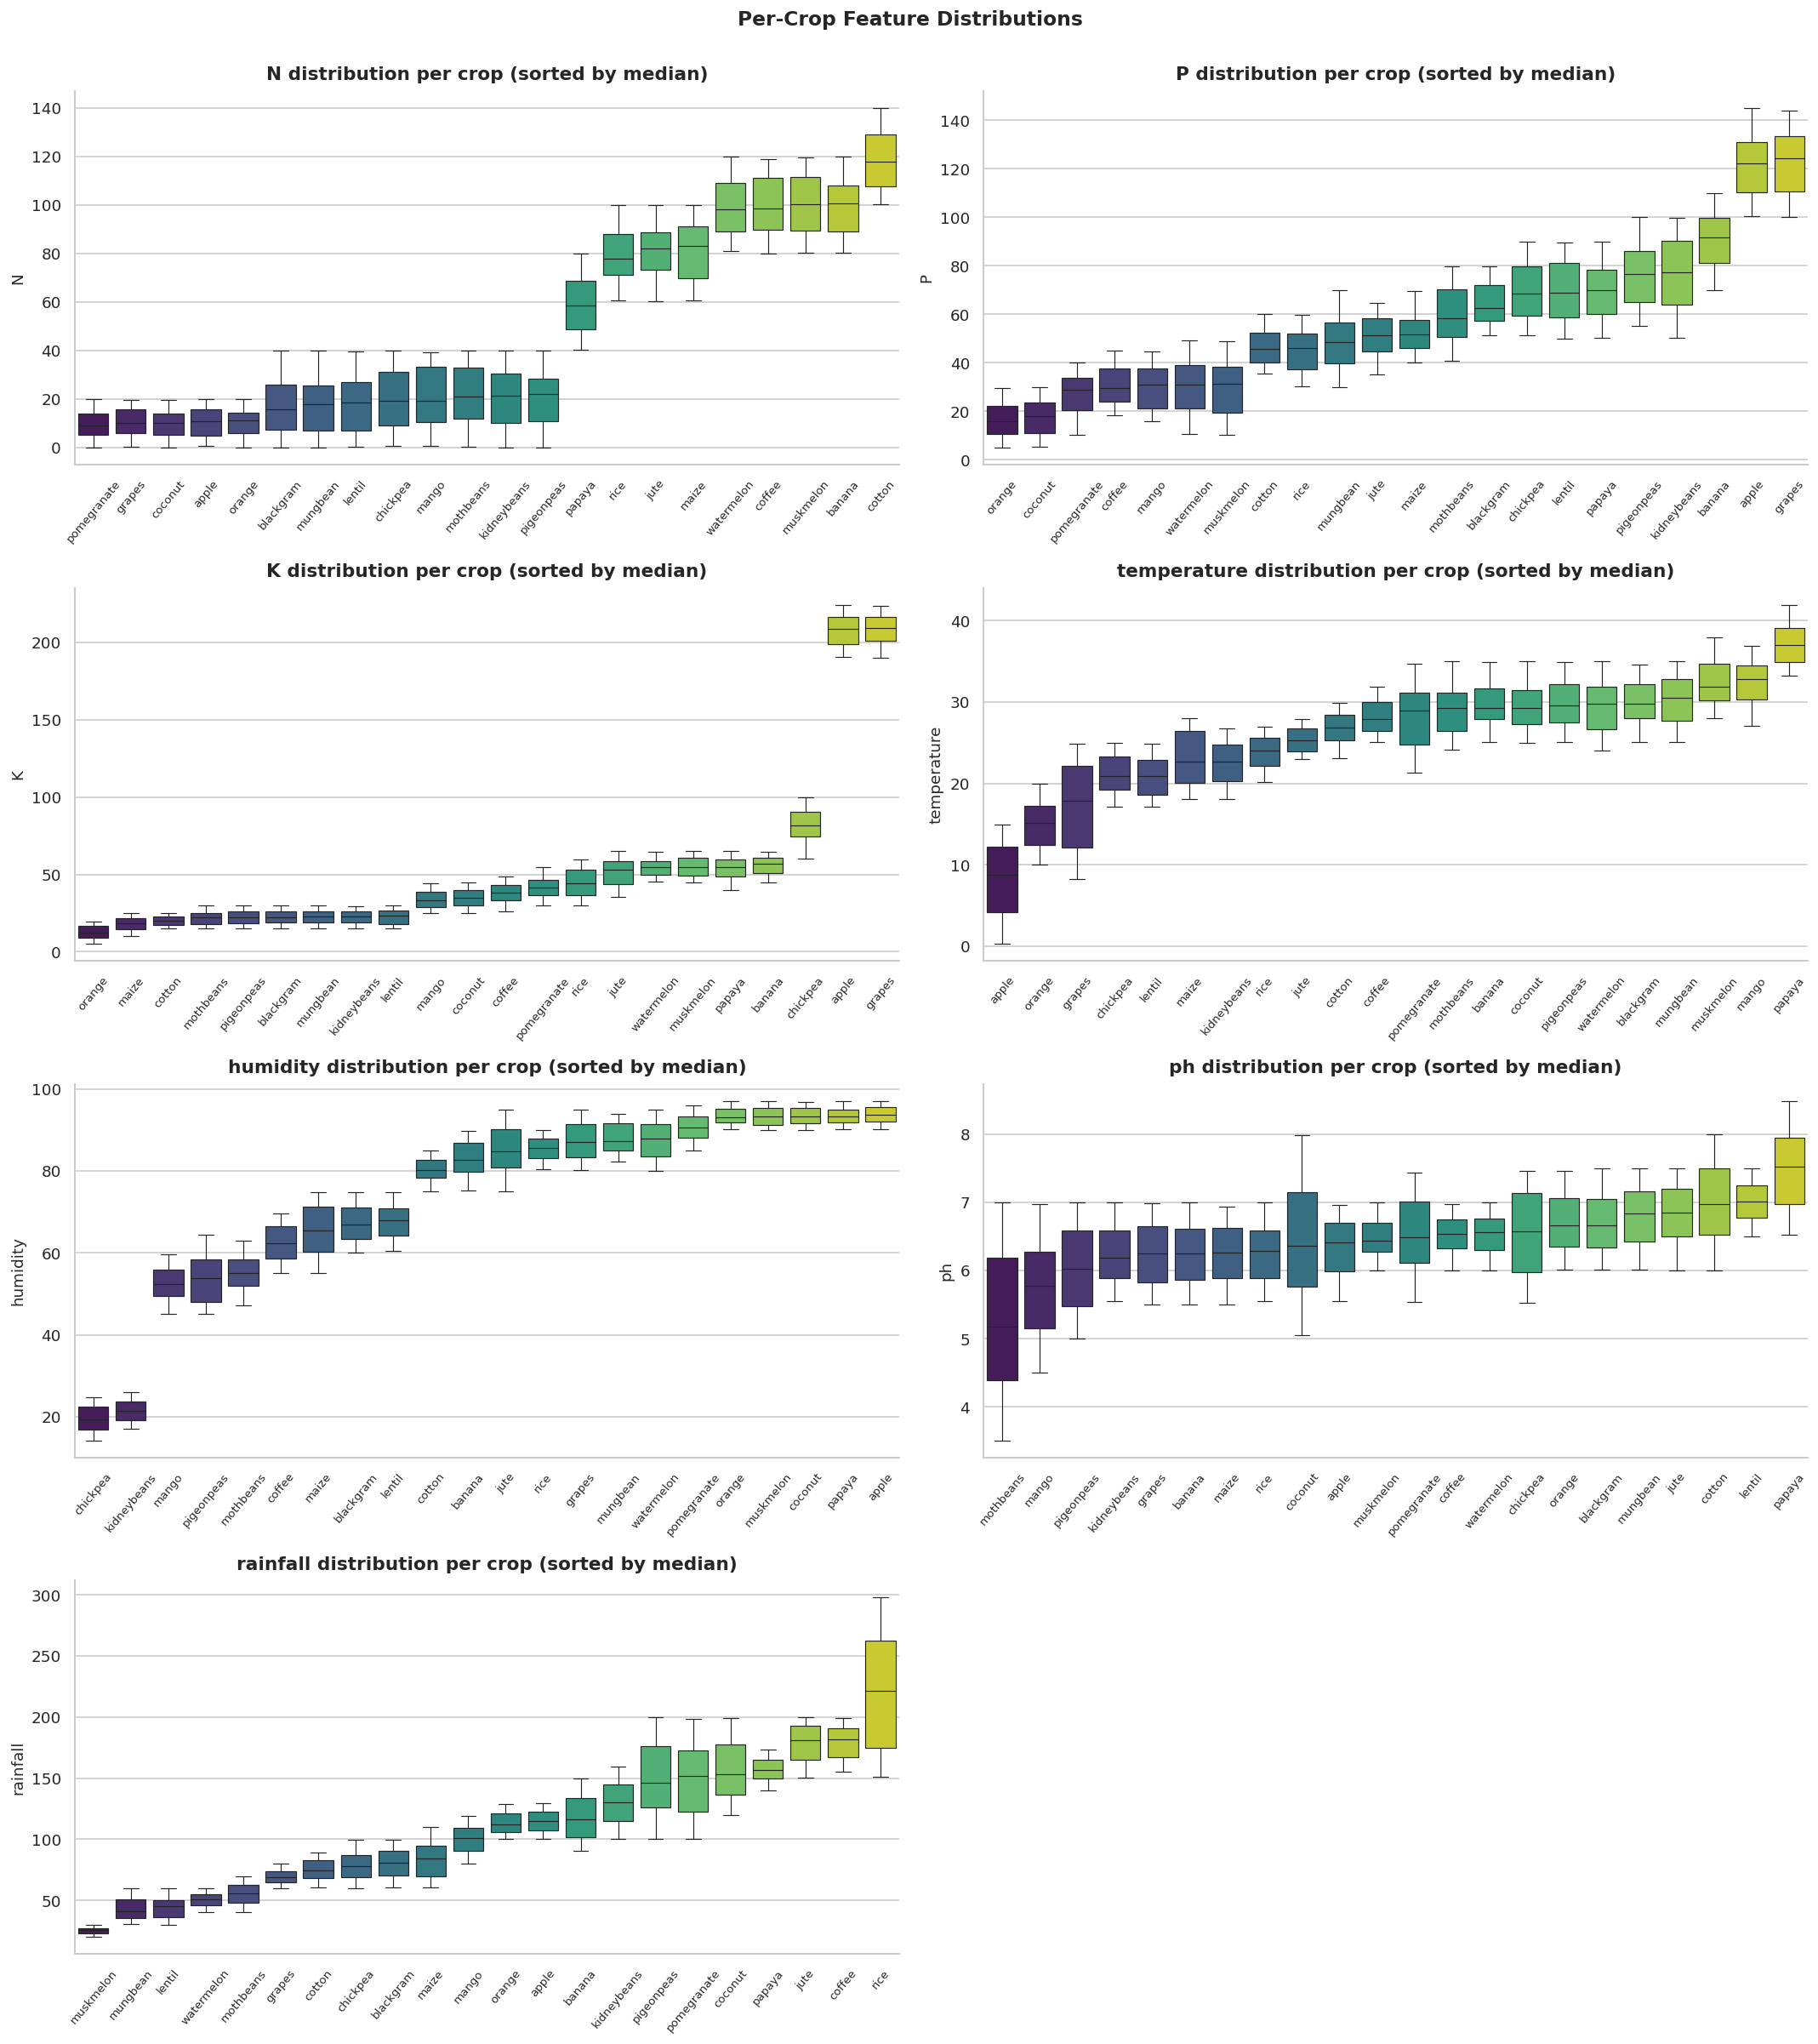

In [ ]:
# ── Box plots of every feature per crop ──────────────────────
fig, axes = plt.subplots(4, 2, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLUMNS):
    order = df.groupby(TARGET_COLUMN)[col].median().sort_values().index
    sns.boxplot(
        data=df, x=TARGET_COLUMN, y=col,
        order=order, ax=axes[i],
        palette='viridis', linewidth=0.7, fliersize=2
    )
    axes[i].set_title(f'{col} distribution per crop (sorted by median)',
                      fontweight='bold', pad=8)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=50, labelsize=8)

axes[-1].axis('off')   # hide spare subplot
plt.suptitle('Per-Crop Feature Distributions', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

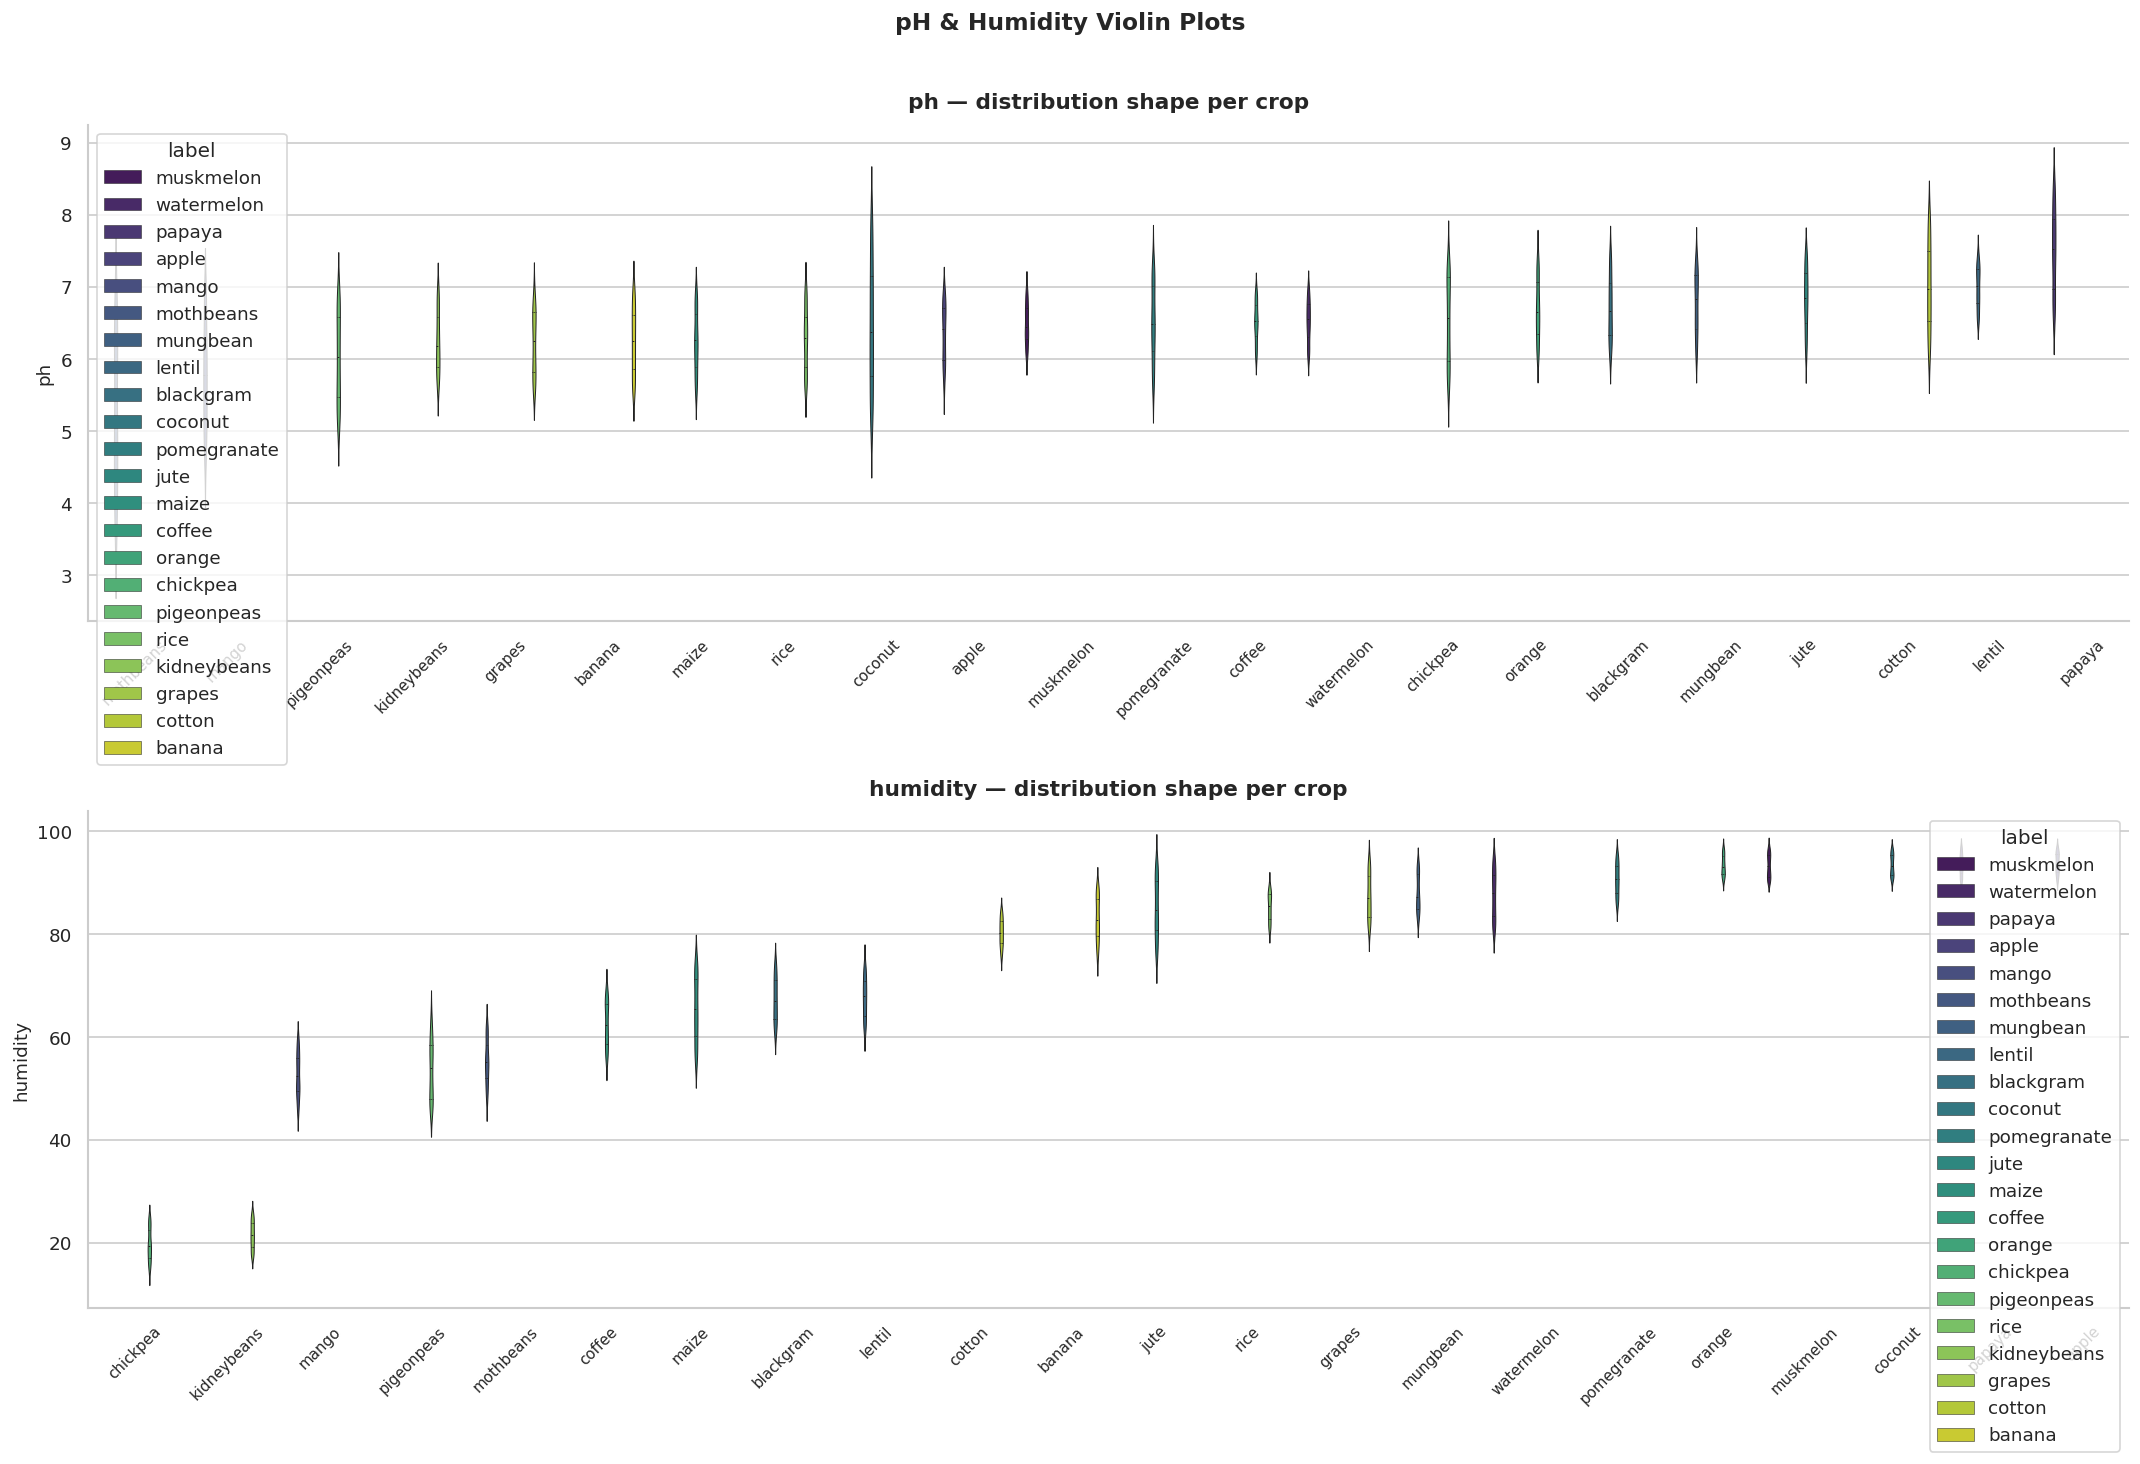


💡 Violin plots reveal the FULL distribution shape, not just quartiles.
   Look for bimodal shapes (two humps) — these suggest subgroups within a crop.


In [ ]:
# ── Violin plots for pH and humidity (bimodality check) ──────
fig, axes = plt.subplots(2, 1, figsize=(18, 12))

for ax, feat in zip(axes, ['ph', 'humidity']):
    order = df.groupby(TARGET_COLUMN)[feat].median().sort_values().index
    sns.violinplot(
        data=df, x=TARGET_COLUMN, y=feat,
        order=order, ax=ax,
        hue=TARGET_COLUMN, legend=False,
        palette='viridis',
        inner='quartile', linewidth=0.6,
        density_norm='width'
    )
    ax.set_title(f'{feat} — distribution shape per crop', fontweight='bold', pad=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45, labelsize=9)

plt.suptitle('pH & Humidity Violin Plots', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\n💡 Violin plots reveal the FULL distribution shape, not just quartiles.')
print('   Look for bimodal shapes (two humps) — these suggest subgroups within a crop.')

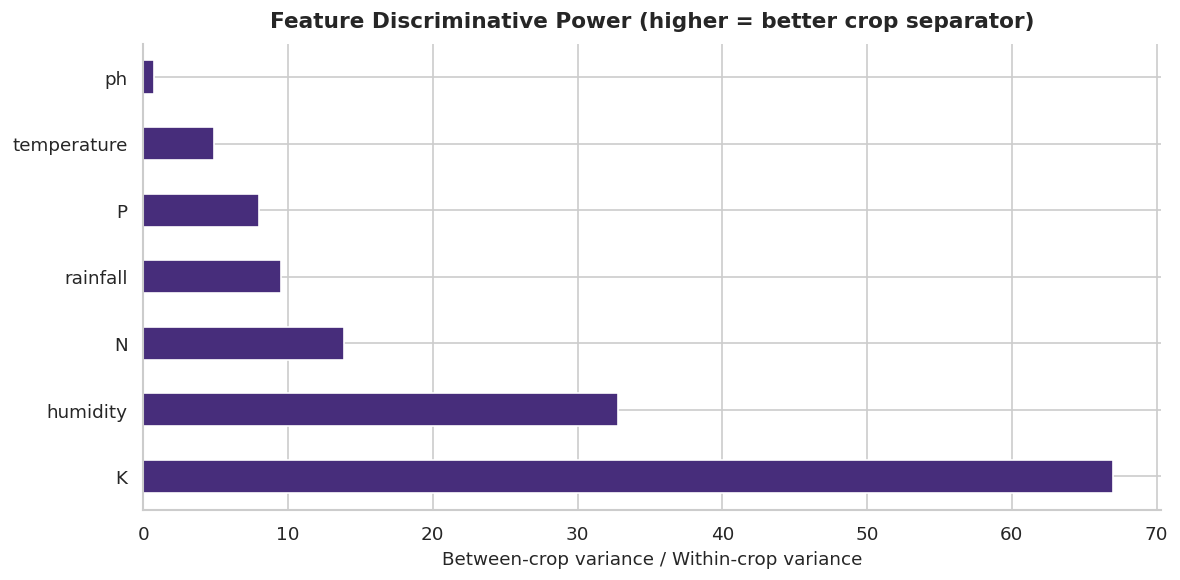


── Feature Discriminative Ranking ──
  1. K            ratio =  66.95
  2. humidity     ratio =  32.80
  3. N            ratio =  13.89
  4. rainfall     ratio =   9.54
  5. P            ratio =   7.99
  6. temperature  ratio =   4.87
  7. ph           ratio =   0.74


In [ ]:
# ── Which features best discriminate between crops? ──────────
# For each feature, compute the ratio of between-crop variance to within-crop variance
# (a simplified version of the ANOVA F-statistic)

discriminability = {}
for col in FEATURE_COLUMNS:
    between  = df.groupby(TARGET_COLUMN)[col].mean().var()
    within   = df.groupby(TARGET_COLUMN)[col].var().mean()
    discriminability[col] = between / within if within > 0 else np.nan

disc_df = pd.DataFrame.from_dict(discriminability, orient='index',
                                  columns=['between/within ratio'])
disc_df = disc_df.sort_values('between/within ratio', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
disc_df.plot(kind='barh', ax=ax, color=sns.color_palette('viridis', 7),
             legend=False, edgecolor='white')
ax.set_title('Feature Discriminative Power (higher = better crop separator)',
             fontweight='bold', pad=10)
ax.set_xlabel('Between-crop variance / Within-crop variance')
plt.tight_layout()
plt.show()

print('\n── Feature Discriminative Ranking ──')
for i, (feat, row) in enumerate(disc_df.iterrows(), 1):
    print(f'  {i}. {feat:<12} ratio = {row["between/within ratio"]:6.2f}')

## 8. Bivariate Relationships (Pairplot)

A pairplot shows every feature against every other feature, coloured by crop class. We use a representative subset of six crops for readability — plotting all 22 would be too visually dense.

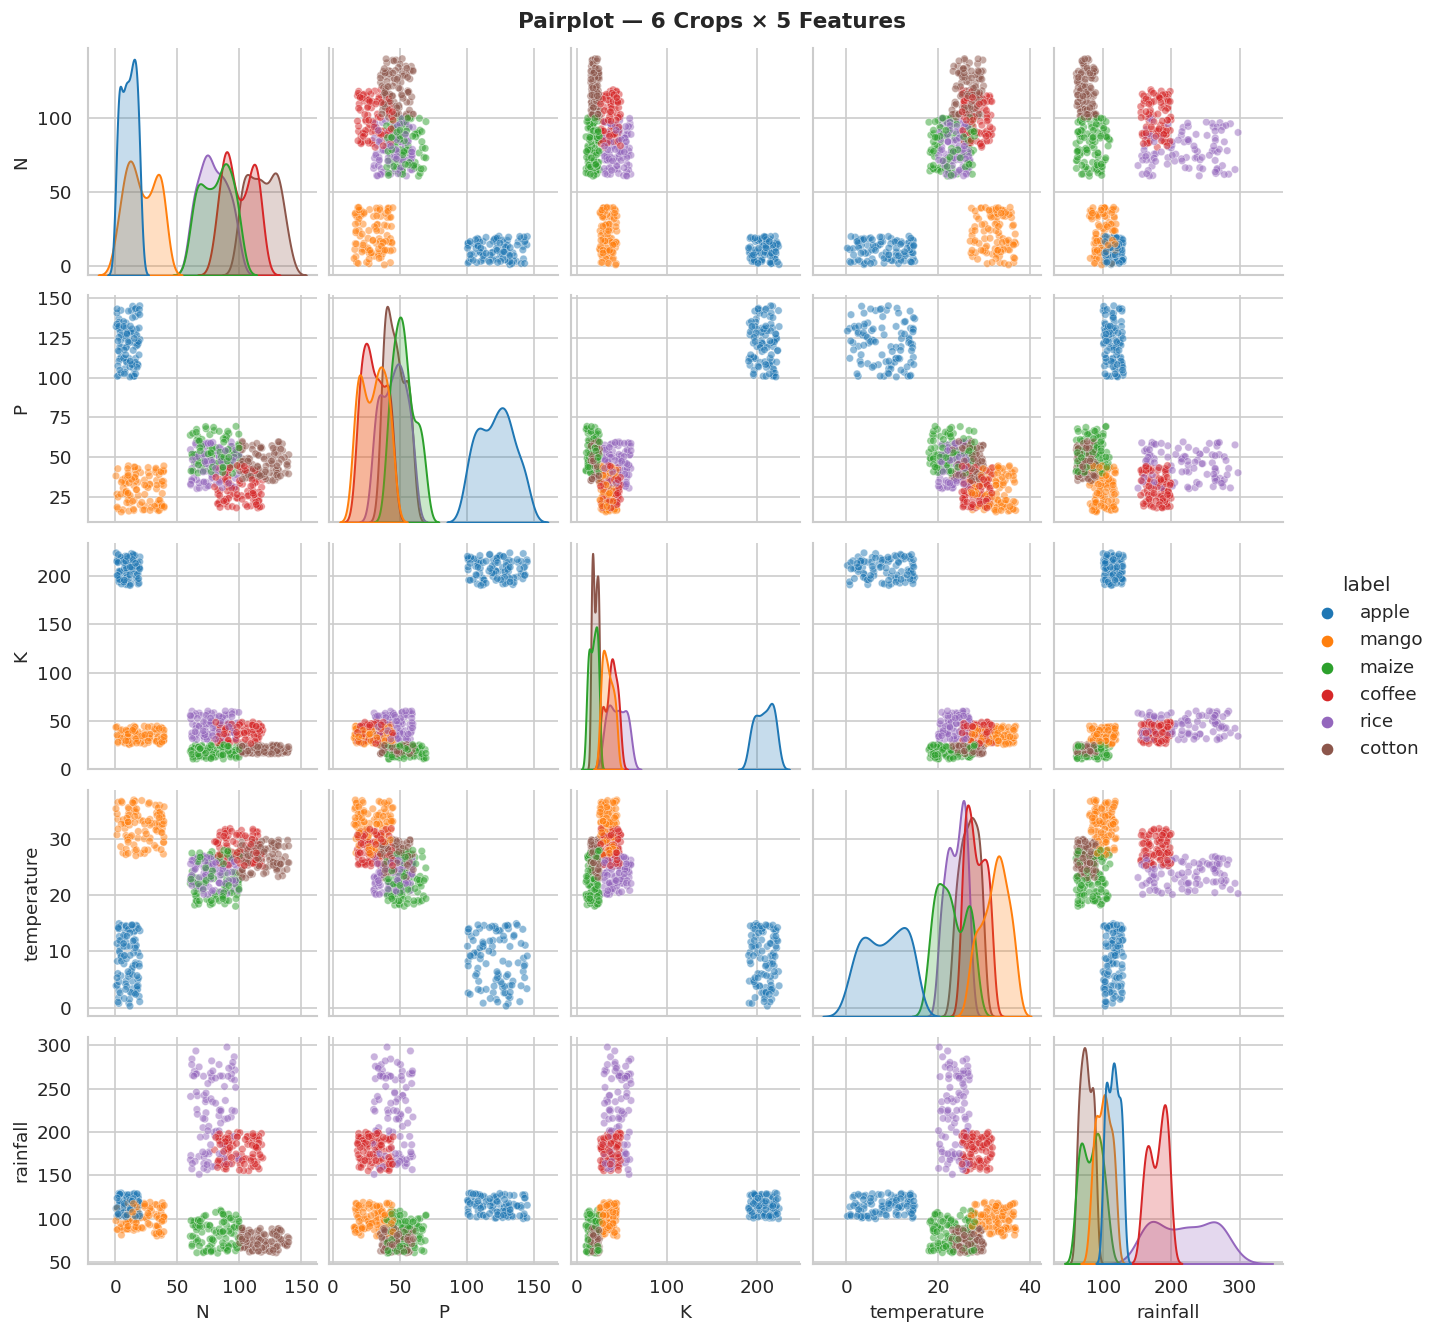

In [ ]:
# ── Pairplot on a subset of crops ────────────────────────────
subset_crops = ['rice', 'maize', 'mango', 'cotton', 'coffee', 'apple']
available = [c for c in subset_crops if c in df[TARGET_COLUMN].unique()]

sub = df[df[TARGET_COLUMN].isin(available)]
pair_cols = ['N', 'P', 'K', 'temperature', 'rainfall', TARGET_COLUMN]

pp = sns.pairplot(
    sub[pair_cols], hue=TARGET_COLUMN,
    palette='tab10', diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 20},
    diag_kws={'linewidth': 1.2}, height=2.2
)
pp.fig.suptitle(f'Pairplot — {len(available)} Crops × 5 Features',
                 y=1.01, fontsize=13, fontweight='bold')
plt.show()

## 9. Outlier Detection

We use the IQR (Inter-Quartile Range) method: any value more than 1.5 × IQR beyond the quartile boundaries is flagged. This is a data quality check — some outliers are legitimate extreme values, while others may indicate data entry errors.

In [ ]:
# ── IQR-based outlier counting ───────────────────────────────
outlier_summary = {}
for col in FEATURE_COLUMNS:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct   = n_out / len(df) * 100
    outlier_summary[col] = {
        'lower_bound': round(lower, 2),
        'upper_bound': round(upper, 2),
        'n_outliers':  int(n_out),
        'pct':         round(pct, 2),
    }

outlier_df = pd.DataFrame(outlier_summary).T
outlier_df

,lower_bound,upper_bound,n_outliers,pct
N,-98.73,195.90,0.0,0.00
P,-25.75,134.75,37.0,1.68
K,-27.11,104.83,200.0,9.09
temperature,10.46,42.93,81.0,3.68
humidity,15.45,136.69,8.0,0.36
ph,4.84,8.12,66.0,3.00
rainfall,-64.45,278.31,6.0,0.27


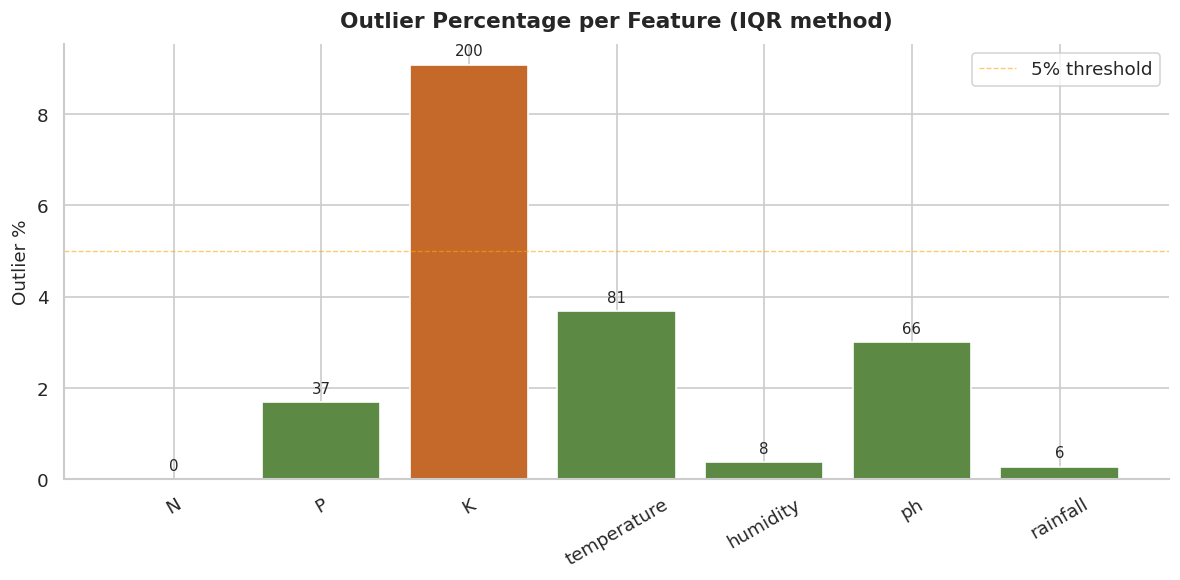


💡 Total outlier observations flagged: 398
   Note: these are NOT removed automatically. In crop data, extreme values
   often correspond to specialised crops (e.g. very high potassium = grapes/apple).


In [ ]:
# ── Visualise outliers per feature ───────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
colours = ['#5C8A44' if p < 5 else '#C4692A' if p < 10 else '#C0392B'
           for p in outlier_df['pct']]
ax.bar(outlier_df.index, outlier_df['pct'], color=colours, edgecolor='white')
ax.set_title('Outlier Percentage per Feature (IQR method)', fontweight='bold', pad=10)
ax.set_ylabel('Outlier %')
ax.axhline(5, color='orange', linestyle='--', linewidth=0.8, alpha=0.6, label='5% threshold')
ax.legend()
for i, (feat, row) in enumerate(outlier_df.iterrows()):
    ax.text(i, row['pct'] + 0.2, f'{int(row["n_outliers"])}',
            ha='center', fontsize=9)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

total_out = int(outlier_df['n_outliers'].sum())
print(f'\n💡 Total outlier observations flagged: {total_out}')
print('   Note: these are NOT removed automatically. In crop data, extreme values\n'
      '   often correspond to specialised crops (e.g. very high potassium = grapes/apple).')

## 10. Secondary Dataset — Soil Properties Analysis

The secondary dataset (Mendeley Data) contains physical and chemical soil characterisations. It is used for contextual discussion in the dissertation — we do NOT merge it into the ML pipeline because its schema differs from the primary dataset.

In [ ]:
# ── Load the secondary dataset (returns None if absent) ──────
soil_df = load_soil_dataset()

if soil_df is not None:
    print(f'Soil Dataset: {soil_df.shape[0]} rows × {soil_df.shape[1]} columns\n')
    print('── Columns ──')
    for col in soil_df.columns:
        print(f'  {col:<30} ({soil_df[col].dtype})')
    print('\n── Sample rows ──')
    display(soil_df.head())
else:
    print('⚠️  Secondary soil dataset not found.')
    print('   Download from: https://data.mendeley.com/datasets/36xkf32pph/1')
    print('   Place as: data/soil_dataset.csv')
    print('   Skipping Section 10 — remaining notebook cells will still run.')

10:13:46 | INFO | Loaded soil dataset: 456 rows × 22 columns


Soil Dataset: 456 rows × 22 columns

── Columns ──
  Region                         (object)
  Sample_Number                  (int64)
  Village_Name                   (object)
  Sand (%)                       (float64)
  Silt (%)                       (float64)
  Clay (%)                       (float64)
  Texture                        (object)
  OC (%)                         (float64)
  pH                             (float64)
  EC (dS m-1)                    (float64)
  Av. N (kg ha-1)                (float64)
  Av. P (kg ha-1)                (float64)
  Av. K (kg ha-1)                (float64)
  Av. S (mg kg-1)                (float64)
  Av. Fe (mg kg-1)               (float64)
  Av. Mn (mg kg-1)               (float64)
  Av. Zn (mg kg-1)               (float64)
  Av. Cu (mg kg-1)               (float64)
  Clusters                       (object)
  Latitude                       (float64)
  Longidtude                     (float64)
  Farmers Name                   (object)

── Sample

,Region,Sample_Number,Village_Name,Sand (%),Silt (%),Clay (%),Texture,OC (%),pH,EC (dS m-1),...,Av. K (kg ha-1),Av. S (mg kg-1),Av. Fe (mg kg-1),Av. Mn (mg kg-1),Av. Zn (mg kg-1),Av. Cu (mg kg-1),Clusters,Latitude,Longidtude,Farmers Name
0,Akole,1,Chichondi,40.6,13.8,45.6,Clay,0.68,6.59,0.3505,...,349.44,8.40,1.65,5.760,0.413,0.750,Akole,19.5612,73.7666,Popat maruthi Jadhav
1,Akole,2,Chichondi,36.6,29.9,33.5,Clay loam,0.40,6.19,0.1786,...,210.20,6.50,3.63,3.910,0.211,0.480,NaN,19.5696,73.7637,Ganpath nagu Ghare
2,Akole,3,Murshet,20.2,20.6,59.2,Clay,0.60,6.71,0.2500,...,249.60,8.50,2.64,5.055,0.275,0.620,NaN,19.5470,73.7471,Sahebrav ganpath bhandkoli
3,Akole,4,Murshet,34.7,17.1,48.2,Clay,0.39,6.43,0.1791,...,236.20,6.80,1.93,3.858,0.218,0.468,NaN,19.5458,73.7420,Raju kama gangad
4,Akole,5,Murshet,8.9,19.5,71.6,Clay,0.82,7.03,0.3500,...,266.50,10.56,4.10,5.500,0.401,0.991,NaN,19.5455,73.7396,Tukaram bhika golwad


In [ ]:
if soil_df is not None:
    # ── Descriptive statistics for the soil dataset ──
    numeric_cols = soil_df.select_dtypes(include=[np.number]).columns.tolist()
    print(f'Numeric columns: {len(numeric_cols)}')
    display(soil_df[numeric_cols].describe().round(3))

Numeric columns: 17


,Sample_Number,Sand (%),Silt (%),Clay (%),OC (%),pH,EC (dS m-1),Av. N (kg ha-1),Av. P (kg ha-1),Av. K (kg ha-1),Av. S (mg kg-1),Av. Fe (mg kg-1),Av. Mn (mg kg-1),Av. Zn (mg kg-1),Av. Cu (mg kg-1),Latitude,Longidtude
count,456.00,456.000,456.000,456.000,456.000,456.000,456.000,456.000,456.000,456.000,165.000,456.000,456.000,456.000,456.000,165.000,165.000
mean,228.50,58.196,15.833,25.960,0.608,6.133,0.261,112.359,7.784,216.337,6.876,1.310,2.922,0.149,0.427,19.579,73.738
std,131.78,18.423,7.719,13.348,0.270,0.515,0.112,42.276,4.517,78.726,1.231,0.926,1.446,0.111,0.228,0.023,0.015
min,1.00,3.500,3.800,7.560,0.039,4.950,0.048,25.088,0.100,73.920,4.600,0.095,0.012,0.003,0.005,19.537,73.708
25%,114.75,41.675,10.200,16.500,0.378,5.700,0.177,75.264,5.413,165.060,6.000,0.658,1.962,0.085,0.277,19.562,73.724
50%,228.50,66.700,13.100,20.400,0.560,6.110,0.251,112.896,6.896,203.520,6.800,1.019,2.925,0.114,0.386,19.574,73.740
75%,342.25,72.640,20.300,32.700,0.800,6.470,0.327,138.813,9.334,249.640,7.600,1.810,4.044,0.184,0.570,19.602,73.749
max,456.00,81.300,40.500,76.300,1.443,7.700,0.996,301.056,46.523,664.160,10.800,4.520,6.290,0.759,1.269,19.626,73.767


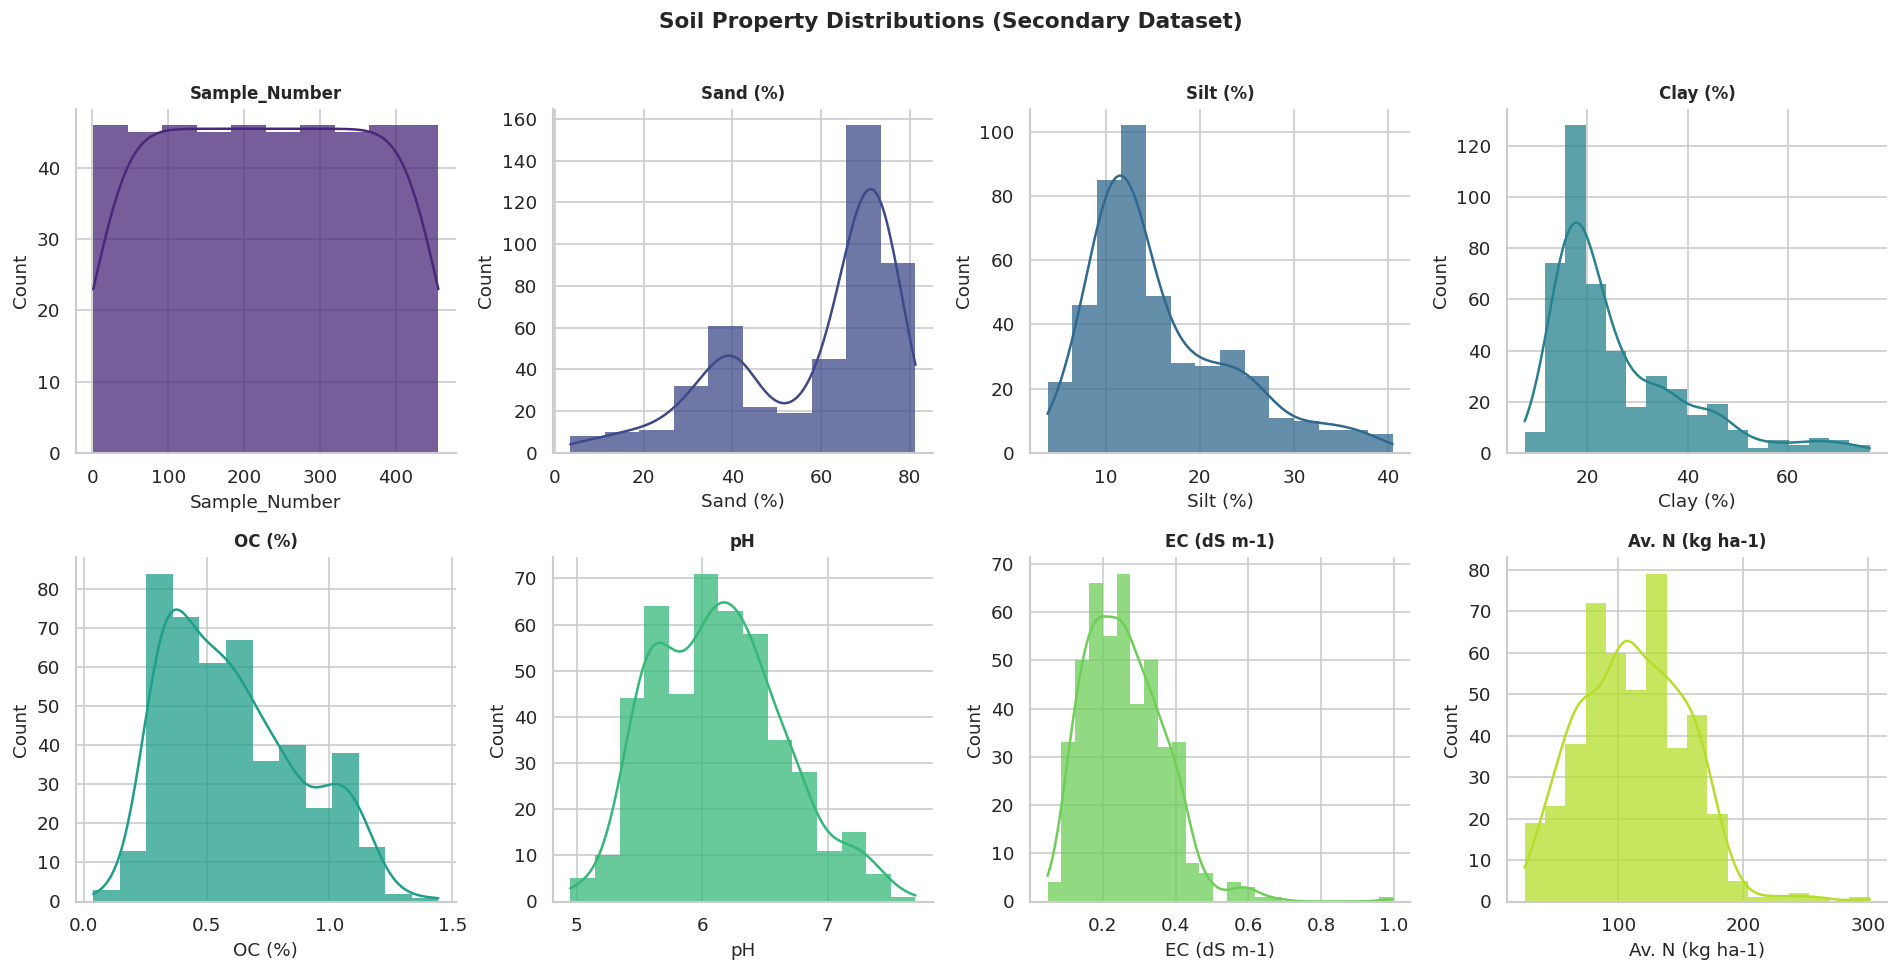

In [ ]:
if soil_df is not None:
    # ── Distribution plots for up to 8 numeric soil properties ──
    numeric_cols = soil_df.select_dtypes(include=[np.number]).columns.tolist()
    n_show = min(8, len(numeric_cols))

    ncols = 4
    nrows = int(np.ceil(n_show / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
    axes = axes.flatten()

    pal = sns.color_palette('viridis', n_show)
    for i in range(n_show):
        col = numeric_cols[i]
        data = soil_df[col].dropna()
        sns.histplot(data, kde=True, ax=axes[i], color=pal[i], alpha=0.75, linewidth=0)
        axes[i].set_title(col, fontweight='bold', fontsize=10)

    for j in range(n_show, len(axes)):
        axes[j].axis('off')

    plt.suptitle('Soil Property Distributions (Secondary Dataset)',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

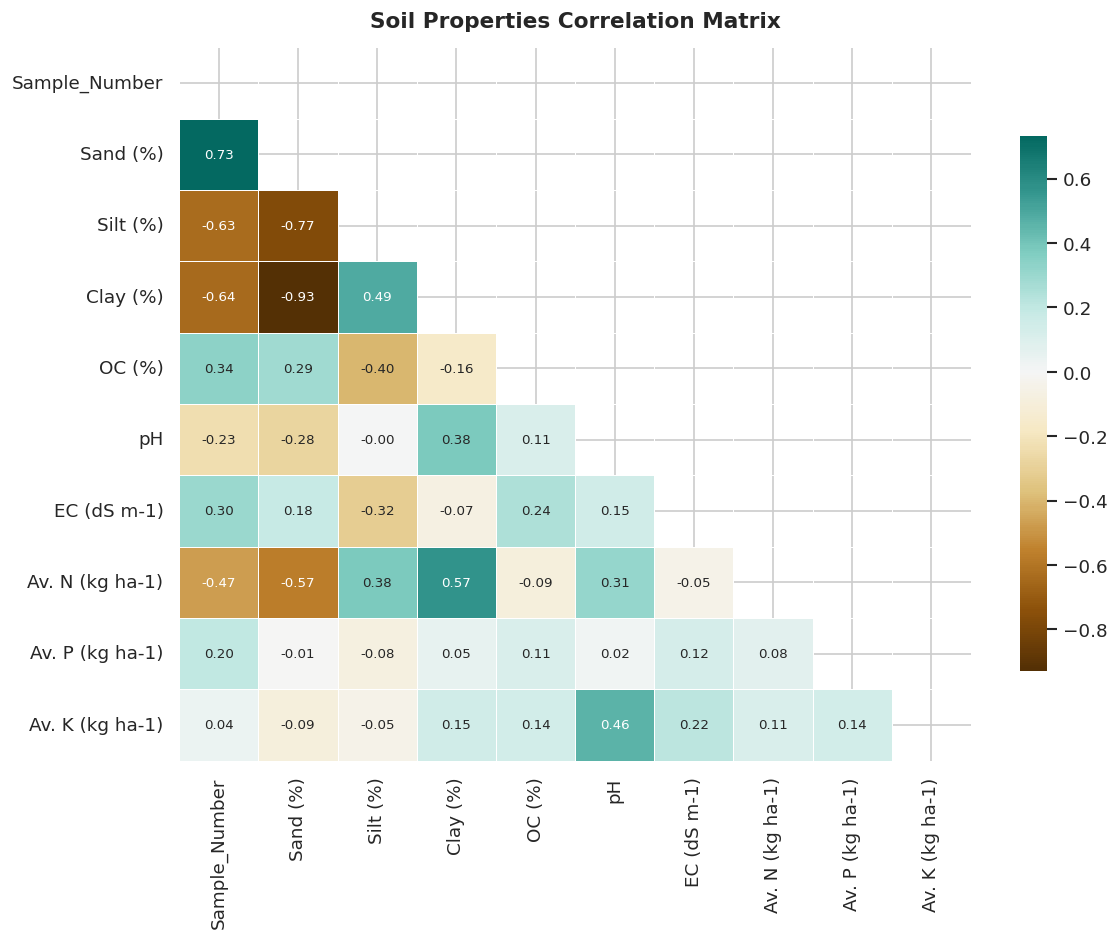

In [ ]:
if soil_df is not None:
    # ── Soil properties correlation matrix ──
    numeric_cols = soil_df.select_dtypes(include=[np.number]).columns.tolist()[:10]
    corr_soil = soil_df[numeric_cols].corr()

    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr_soil, dtype=bool))
    sns.heatmap(
        corr_soil, mask=mask, annot=True, fmt='.2f',
        cmap='BrBG', center=0, linewidths=0.5, ax=ax,
        cbar_kws={'shrink': 0.75}, annot_kws={'fontsize': 8}
    )
    ax.set_title('Soil Properties Correlation Matrix', fontsize=13, fontweight='bold', pad=12)
    plt.tight_layout()
    plt.show()

## 11. Key Findings Summary

This final section consolidates the key observations from our EDA. These findings directly inform the modelling decisions in `train_model.py`.

In [ ]:
print('═' * 60)
print('  EDA KEY FINDINGS — CROP RECOMMENDATION DATASET')
print('═' * 60)

print(f'\n📊  DATASET OVERVIEW')
print(f'    · Total records:    {len(df):,}')
print(f'    · Total features:   {len(FEATURE_COLUMNS)} numeric')
print(f'    · Total classes:    {df[TARGET_COLUMN].nunique()}')
print(f'    · Missing values:   {df.isnull().sum().sum()}')
print(f'    · Duplicate rows:   {df.duplicated().sum()}')

print(f'\n⚖️  CLASS BALANCE')
min_c = dist["count"].min()
max_c = dist["count"].max()
print(f'    · Records per crop: {min_c}–{max_c}')
print(f'    · Imbalance ratio:  {max_c/min_c:.2f}× — '
      f'{"near-perfectly balanced ✓" if max_c/min_c < 1.1 else "moderate imbalance"}')

print(f'\n📈  FEATURE DISTRIBUTIONS')
for feat in FEATURE_COLUMNS:
    skew = stats.loc[feat, "skewness"]
    shape = "symmetric" if abs(skew) < 0.5 else ("right-skewed" if skew > 0 else "left-skewed")
    print(f'    · {feat:<13}: {shape} (skew={skew:+.2f})')

print(f'\n🔗  CORRELATION')
max_abs_corr = max(abs(p[2]) for p in pairs)
print(f'    · Maximum |r|: {max_abs_corr:.3f}')
print(f'    · Conclusion:  {"low multicollinearity — features are largely independent" if max_abs_corr < 0.5 else "some correlation between features"}')

print(f'\n🎯  MOST DISCRIMINATIVE FEATURES (by variance ratio)')
for i, (feat, _) in enumerate(disc_df.head(3).iterrows(), 1):
    print(f'    {i}. {feat}')

print(f'\n⚠️  OUTLIERS')
print(f'    · Total observations flagged: {total_out}')
print(f'    · Retained for modelling (likely represent specialised crops)')

print(f'\n💡  MODELLING IMPLICATIONS')
print(f'    1. Balanced classes — no resampling needed')
print(f'    2. Low correlation — all 7 features provide independent signal')
print(f'    3. Clear separability — Random Forest expected to perform well')
print(f'    4. Mixed scales — StandardScaler required before training')
print(f'    5. Tree-based models robust to remaining skewness')

print(f'\n{"═" * 60}')
print(f'  ✓ EDA COMPLETE — Ready for model training')
print(f'{"═" * 60}')

════════════════════════════════════════════════════════════
  EDA KEY FINDINGS — CROP RECOMMENDATION DATASET
════════════════════════════════════════════════════════════

📊  DATASET OVERVIEW
    · Total records:    2,200
    · Total features:   7 numeric
    · Total classes:    22
    · Missing values:   0
    · Duplicate rows:   0

⚖️  CLASS BALANCE
    · Records per crop: 100–100
    · Imbalance ratio:  1.00× — near-perfectly balanced ✓

📈  FEATURE DISTRIBUTIONS
    · N            : right-skewed (skew=+0.54)
    · P            : right-skewed (skew=+0.72)
    · K            : right-skewed (skew=+2.33)
    · temperature  : left-skewed (skew=-0.83)
    · humidity     : left-skewed (skew=-1.16)
    · ph           : left-skewed (skew=-0.55)
    · rainfall     : right-skewed (skew=+0.54)

🔗  CORRELATION
    · Maximum |r|: 0.655
    · Conclusion:  some correlation between features

🎯  MOST DISCRIMINATIVE FEATURES (by variance ratio)
    1. K
    2. humidity
    3. N

⚠️  OUTLIERS
    · Tot

---

## Next Steps

The insights from this EDA directly inform the ML pipeline:

1. **No resampling needed** — the balanced class distribution means we can use standard stratified train/test splitting
2. **StandardScaler** — the mixed feature scales (pH in 0–14 vs Rainfall in 20–3000) require standardisation
3. **Tree-based models first** — Random Forest and Gradient Boosting handle the moderate skewness without requiring transformation
4. **5-fold Stratified CV** — appropriate for multiclass balanced data
5. **Macro F1** as primary metric — treats all crop classes equally

### To continue

Run the full ML pipeline:

```bash
python src/train_model.py      # train and compare 3 models
python src/tune_model.py       # hyperparameter optimisation
python src/explain_model.py    # SHAP feature importance
python app/app.py              # launch the web application
```